<a href="https://colab.research.google.com/github/arigalli-data/saas-churn-analysis/blob/main/ravenstack_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RavenStack SaaS Churn Analysis
### End-to-end churn prediction: from EDA to ML modeling and business impact

## Problem Definition
- **Business question:** How many users will leave in the next 30 days
  and how much MRR will we lose?
- **Target:** `churn_flag` = True (churned) / False (retained)
- **Success metrics:** AUC-ROC > 0.80, Recall > 70%
- **End users:** Product Managers and Customer Service Managers
  for retention actions

## Executive Summary

This analysis investigates churn drivers and revenue impact for RavenStack,
a fictional AI-powered SaaS platform.

**Key Findings:**

- **10% of subscriptions have churned**, with churn rate consistent across
  plan tiers, industries, and countries — no single segment is
  disproportionately at risk.
- **Technical friction does not drive churn:** error rates are virtually
  identical between churned and active subscriptions.
- **Support experience is not a primary churn driver:** satisfaction scores,
  resolution time, and ticket volume show no meaningful difference between
  churned and retained accounts.
- **No single churn reason dominates:** reason codes are evenly distributed
  across pricing, features, support, budget, and competition — suggesting
  churn is multi-causal.
- **Churn is a revenue priority:** 10.4% of total MRR (\$1.17M/month) has
  already been lost. Churned users had a slightly higher average MRR than
  active ones — meaning RavenStack is losing its most valuable customers,
  not just trial accounts.

**Result:** three ML models were tested (Logistic Regression, Random Forest,
XGBoost). Due to weak predictive signal in the dataset, targets were not
achieved — see Model Comparison & Conclusion for details and next steps.

In [94]:
!pip install shap scikit-learn xgboost
# !pip install kagglehub[pandas-datasets]  # uncomment if needed

In [95]:
import os, shutil
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

COLORS = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51']

In [96]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ⚠️ Setup: update file_path to your local directory or Google Drive path
# Dataset available at:
# https://www.kaggle.com/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset

base_path = '/content/drive/My Drive/Projects/saas-churn-project/'
file_path = base_path + 'data/raw/'
visual_path = base_path + 'visuals/'

# Ensure the target directory on Google Drive exists
os.makedirs(file_path, exist_ok=True)
os.makedirs(visual_path, exist_ok=True)

# Data download from Kaggle (only first time).
existing_files = os.listdir(file_path)

if not existing_files:
    print("Dataset not found on Drive. Downloading...")
    path = kagglehub.dataset_download("rivalytics/saas-subscription-and-churn-analytics-dataset")

    for filename in os.listdir(path):
        source_file = os.path.join(path, filename)
        destination_file = os.path.join(file_path, filename)
        if os.path.isfile(source_file):
            shutil.copy(source_file, destination_file)
            print(f"  - Copied '{filename}'")
    print("Downloading and copying complete.")
else:
    print(f"Skip download.")

print("Files in Google Drive raw data directory:", os.listdir(file_path))


Mounted at /content/drive
Skip download.
Files in Google Drive raw data directory: ['ravenstack_accounts.csv', 'ravenstack_support_tickets.csv', 'ravenstack_subscriptions.csv', 'README.md', 'ravenstack_feature_usage.csv', 'ravenstack_churn_events.csv']


In [97]:
accounts = pd.read_csv(file_path + 'ravenstack_accounts.csv')
subscriptions = pd.read_csv(file_path + 'ravenstack_subscriptions.csv')
feature_usage = pd.read_csv(file_path + 'ravenstack_feature_usage.csv')
support_tickets = pd.read_csv(file_path + 'ravenstack_support_tickets.csv')
churn_events = pd.read_csv(file_path + 'ravenstack_churn_events.csv')

In [98]:
datasets = {
    'accounts': accounts,
    'subscriptions': subscriptions,
    'feature_usage': feature_usage,
    'support_tickets': support_tickets,
    'churn_events': churn_events
}

for name, df in datasets.items():
    print(f"\n{name}:")
    print(f"Shape: {df.shape}")
    print(df.dtypes)
    print(df.head())


accounts:
Shape: (500, 10)
account_id         object
account_name       object
industry           object
country            object
signup_date        object
referral_source    object
plan_tier          object
seats               int64
is_trial             bool
churn_flag           bool
dtype: object
  account_id account_name    industry country signup_date referral_source  \
0   A-2e4581    Company_0      EdTech      US  2024-10-16         partner   
1   A-43a9e3    Company_1     FinTech      IN  2023-08-17           other   
2   A-0a282f    Company_2    DevTools      US  2024-08-27         organic   
3   A-1f0ac7    Company_3  HealthTech      UK  2023-08-27           other   
4   A-ce550d    Company_4  HealthTech      US  2024-10-27           event   

    plan_tier  seats  is_trial  churn_flag  
0       Basic      9     False       False  
1       Basic     18     False        True  
2       Basic      1     False       False  
3       Basic     24      True       False  
4  Enterpr

## Data quality

In [99]:
# Parsing dates:
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date'] = pd.to_datetime(subscriptions['end_date'])
feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])
support_tickets['submitted_at'] = pd.to_datetime(support_tickets['submitted_at'])
support_tickets['closed_at'] = pd.to_datetime(support_tickets['closed_at'])
churn_events['churn_date'] = pd.to_datetime(churn_events['churn_date'])

In [100]:
# Checking duplicates
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicates")

accounts: 0 duplicates
subscriptions: 0 duplicates
feature_usage: 0 duplicates
support_tickets: 0 duplicates
churn_events: 0 duplicates


In [101]:
# Missing values:
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n{name}:")
        print(missing.to_string())
        print((missing / len(df) * 100).round(1).to_string(), "%")


subscriptions:
end_date    4514
end_date    90.3 %

support_tickets:
satisfaction_score    825
satisfaction_score    41.2 %

churn_events:
feedback_text    148
feedback_text    24.7 %


- Subscriptions: 90% of end_date is missing → active subscriptions, not a data issue
- Support tickets: 41.2% of satisfaction_score is missing → are these unsatisfied users that leave without completing the satisfaction survey?
- Churn events: 24.7% of feedback_text is missing  → free text missing, will evaluate this during the descriptive analysis of churn.

## EDA

In [102]:
for name, df in datasets.items():
    print(f"\n{name}:")
    print(df.describe())


accounts:
                         signup_date       seats
count                            500  500.000000
mean   2024-01-27 06:34:33.600000256   20.560000
min              2023-01-02 00:00:00    1.000000
25%              2023-08-06 18:00:00    5.000000
50%              2024-02-21 00:00:00   15.000000
75%              2024-08-04 06:00:00   28.000000
max              2024-12-31 00:00:00  163.000000
std                              NaN   21.044718

subscriptions:
                       start_date                       end_date        seats  \
count                        5000                            486  5000.000000   
mean   2024-07-14 01:49:43.680000  2024-09-29 09:14:04.444444672    29.852000   
min           2023-01-09 00:00:00            2023-04-05 00:00:00     1.000000   
25%           2024-04-17 18:00:00            2024-08-19 12:00:00    14.000000   
50%           2024-09-01 00:00:00            2024-11-10 12:00:00    24.000000   
75%           2024-11-17 00:00:00            2

In [103]:
for name, df in datasets.items():
    print(f"\n{name}:")
    print(df.describe(include='object'))


accounts:
       account_id account_name  industry country referral_source plan_tier
count         500          500       500     500             500       500
unique        500          500         5       7               5         3
top      A-781cc0  Company_499  DevTools      US         organic       Pro
freq            1            1       113     291             114       178

subscriptions:
       subscription_id account_id   plan_tier billing_frequency
count             5000       5000        5000              5000
unique            5000        500           3                 2
top           S-71fc3d   A-d4ac0e  Enterprise           monthly
freq                 1         19        1723              2539

feature_usage:
        usage_id subscription_id feature_name
count      25000           25000        25000
unique     24979            4967           40
top     U-13ce5b        S-0896f4   feature_12
freq           2              16          659

support_tickets:
       ticket_

In [104]:
for name, df in datasets.items():
    bool_cols = df.select_dtypes(include='bool').columns.tolist()
    if bool_cols:
        print(f"\n{name}:")
        for col in bool_cols:
            print(f"\n{col}:")
            print(df[col].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


accounts:

is_trial:
is_trial
False    80.6%
True     19.4%
Name: proportion, dtype: object

churn_flag:
churn_flag
False    78.0%
True     22.0%
Name: proportion, dtype: object

subscriptions:

is_trial:
is_trial
False    84.4%
True     15.6%
Name: proportion, dtype: object

upgrade_flag:
upgrade_flag
False    89.4%
True     10.6%
Name: proportion, dtype: object

downgrade_flag:
downgrade_flag
False    95.6%
True      4.4%
Name: proportion, dtype: object

churn_flag:
churn_flag
False    90.3%
True      9.7%
Name: proportion, dtype: object

auto_renew_flag:
auto_renew_flag
True     80.1%
False    19.9%
Name: proportion, dtype: object

feature_usage:

is_beta_feature:
is_beta_feature
False    89.8%
True     10.2%
Name: proportion, dtype: object

support_tickets:

escalation_flag:
escalation_flag
False    95.2%
True      4.8%
Name: proportion, dtype: object

churn_events:

preceding_upgrade_flag:
preceding_upgrade_flag
False    79.5%
True     20.5%
Name: proportion, dtype: object

prece

### Dataset Overview:

**Structure & Relationships**
- 500 accounts link to 5,000 subscriptions → average 10 subscriptions per
  account, reflecting plan changes and reactivations over time.
- `account_id` and `account_name` are unique identifiers (no duplicates).

**Accounts & Subscriptions**
- Users span 5 industries; DevTools is the most represented (~22%).
- 7 countries represented; US accounts for more than half of the user base.
- Organic is the most common referral source (~20%).
- Plan distribution is relatively balanced across Basic, Pro, and Enterprise;
  ~50% of subscriptions are billed monthly.
- 19.4% of accounts are currently on trial; 80% of subscriptions
  have auto-renew enabled.
- 22% of accounts have churned; 9.7% of individual subscriptions ended.
- Only 10.6% of subscriptions upgraded and 4.4% downgraded —
  low expansion revenue signal.

**Feature Usage**
- 33 subscriptions show zero feature usage → **zombie accounts**,
  a known strong predictor of churn.
- 40 distinct features tracked; `feature_12` is the most frequently used.
- Beta features account for ~10% of usage events.
- `error_count` median is 0 but max is 8 → technical friction is rare
  but potentially impactful on retention. To be investigated further.

**Support Tickets**
- Some accounts submitted up to 11 tickets → possible signal of
  chronic dissatisfaction.
- ~25% of tickets are flagged as urgent; only 5% were escalated.
- `satisfaction_score` minimum is 3 (scale 1–5) → likely survivorship bias:
  highly dissatisfied users may simply churn without leaving feedback.

**Churn Events**
- 600 churn events across 352 unique accounts → some accounts churned
  multiple times (max: 5), confirming reactivation cycles.
- 20.5% of churners had upgraded within 90 days before leaving →
  upgrades do not guarantee retention.
- 10% of churn events are reactivations — product has recovery potential.
- Most common feedback theme: product perceived as too expensive.
- `refund_amount_usd`: most churners receive no refund (75th percentile = 0);
  a small subset receives significant amounts (max ~$393).

### Group 1 - Who churns?

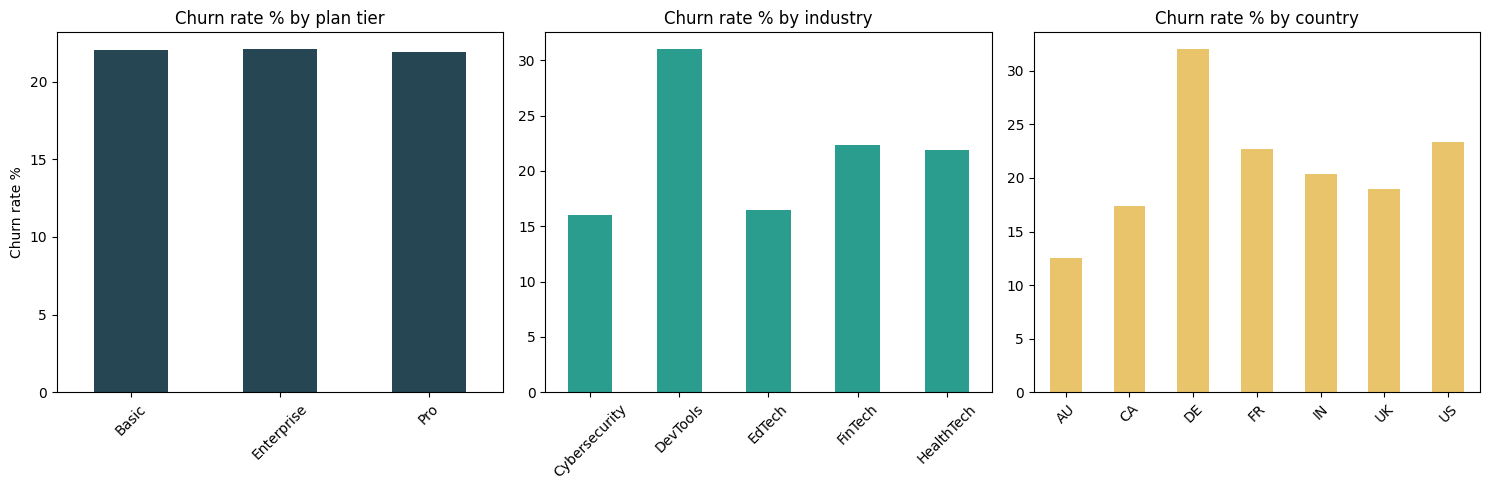

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Churn rate by plan tier
churn_by_plan = accounts.groupby('plan_tier')['churn_flag'].mean() * 100
churn_by_plan.plot(kind='bar', ax=axes[0], color=COLORS[0])
axes[0].set_title('Churn rate % by plan tier')
axes[0].set_ylabel('Churn rate %')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Churn rate by industry
churn_by_industry = accounts.groupby('industry')['churn_flag'].mean() * 100
churn_by_industry.plot(kind='bar', ax=axes[1], color=COLORS[1])
axes[1].set_title('Churn rate % by industry')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Churn rate by country
churn_by_country = accounts.groupby('country')['churn_flag'].mean() * 100
churn_by_country.plot(kind='bar', ax=axes[2], color=COLORS[2])
axes[2].set_title('Churn rate % by country')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [106]:
# Sample size check per group
print(accounts.groupby('industry')['churn_flag'].agg(['sum', 'count']))
print(accounts.groupby('country')['churn_flag'].agg(['sum', 'count']))

               sum  count
industry                 
Cybersecurity   16    100
DevTools        35    113
EdTech          13     79
FinTech         25    112
HealthTech      21     96
         sum  count
country            
AU         4     32
CA         4     23
DE         8     25
FR         5     22
IN        10     49
UK        11     58
US        68    291


Interpretation:
- Churn rate is consistent across all plan tiers (~22%) →
  plan tier is unlikely to be a strong predictor in the model.
- DevTools shows the highest churn rate (~31%), but it is also
  the largest industry segment — absolute numbers should be
  considered before drawing conclusions.
- Germany shows a higher churn rate, but sample size is small —
  this finding requires caution.

### Group2 - Why churn?

#### Zombie accounts

In [107]:
feature_usage_sub = pd.merge(feature_usage, subscriptions, on='subscription_id', how='left')
print(feature_usage_sub.shape)
feature_usage_sub['churn_flag'].value_counts().to_frame().assign(
    proportion=lambda x: x['count'] / x['count'].sum() * 100
).round(1)

(25000, 21)


,count,proportion
churn_flag,,
False,22627,90.5
True,2373,9.5


In [108]:
# Zombie identification:
zombie_subs = subscriptions[
    ~subscriptions['subscription_id'].isin(feature_usage['subscription_id'])
]

print(zombie_subs.shape)
print(zombie_subs['account_id'].value_counts().shape)
zombie_subs['churn_flag'].value_counts()

(33, 14)
(32,)


,count
churn_flag,
False,30
True,3


#### Feature Errors

In [109]:
feature_usage['error_count'].value_counts().to_frame().assign(
    proportion=lambda x: x['count'] / x['count'].sum() * 100
).round(1)

,count,proportion
error_count,,
0,17269,69.1
1,3759,15.0
2,2312,9.2
3,1096,4.4
4,419,1.7
5,113,0.5
6,30,0.1
7,1,0.0
8,1,0.0


In [110]:
mask = feature_usage_sub['error_count'] > 0
feature_usage_sub[mask]['churn_flag'].value_counts().to_frame().assign(
    proportion=lambda x: x['count'] / x['count'].sum() * 100
).round(1)

,count,proportion
churn_flag,,
False,6985,90.4
True,746,9.6


In [111]:
mask_no_errors = feature_usage_sub['error_count'] == 0
feature_usage_sub[mask_no_errors]['churn_flag'].value_counts().to_frame().assign(
    proportion=lambda x: x['count'] / x['count'].sum() * 100
).round(1)

,count,proportion
churn_flag,,
False,15642,90.6
True,1627,9.4


#### Support tickets

In [112]:
support_tickets_acc = pd.merge(support_tickets, accounts, on='account_id', how='left')

In [113]:
tickets_per_account = support_tickets_acc.groupby('account_id').agg(
    ticket_count=('ticket_id', 'count'),
    churned=('churn_flag', 'first')  # Keep only the first value of churn_flag
).reset_index()

In [114]:
tickets_per_account.groupby('ticket_count')['churned'].agg(['sum', 'count']).assign(
    churn_proportion=lambda x: x['sum'] / x['count'] * 100,
    ticket_proportion=lambda x: x['count'] / x['count'].sum() * 100
).round(1)

,sum,count,churn_proportion,ticket_proportion
ticket_count,,,,
1,8,30,26.7,6.1
2,18,74,24.3,15.0
3,27,102,26.5,20.7
4,17,93,18.3,18.9
5,15,97,15.5,19.7
6,9,45,20.0,9.1
7,6,31,19.4,6.3
8,5,11,45.5,2.2
9,2,7,28.6,1.4


In [115]:
# Satisfaction_score:

#how many left without leaving a feeback? Almost 41% (from data quality)

support_tickets_acc.groupby('satisfaction_score')['churn_flag'].agg(['sum','count']).assign(
    churn_rate=lambda x: x['sum'] / x['count'] * 100
).round(1)

,sum,count,churn_rate
satisfaction_score,,,
3.0,80,396,20.2
4.0,97,405,24.0
5.0,83,374,22.2


In [116]:
# Proportion of churn related to the 41% missing tickets:

support_tickets_acc[support_tickets_acc['satisfaction_score'].isna()]['churn_flag'].value_counts(normalize=True) * 100

,proportion
churn_flag,
False,79.151515
True,20.848485


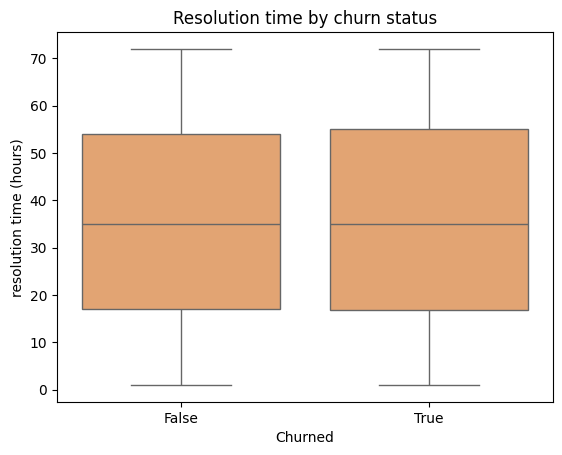

In [117]:
# Resolution_time_hours:
sns.boxplot(data=support_tickets_acc,
            x='churn_flag',
            y='resolution_time_hours',
            color=COLORS[3]
            )
plt.title('Resolution time by churn status')
plt.xlabel('Churned')
plt.ylabel('resolution time (hours)')
plt.show()

#### Churn events

In [118]:
# Reason code:
churn_events['reason_code'].value_counts()

,count
reason_code,
features,114
support,104
budget,104
unknown,95
competitor,92
pricing,91


Interpretation:

10% of feature usage events belong to subscriptions that have churned.


#### Zombie Accounts

Out of 5,000 subscriptions, 33 show zero feature usage (zombie accounts).
Contrary to expectations, only 3 out of 33 zombies churned — suggesting
that most inactive subscriptions belong to early-stage accounts that have
not yet onboarded, rather than disengaged users likely to leave.

One account holds two zombie subscriptions — a minor edge case with no impact on overall findings.


#### Features Errors

31% of feature usage events reported at least one error.

- Churn rate among events **with** errors: 9.6%
- Churn rate among events **without** errors: 9.4%

The two rates are virtually identical, consistent with the overall
churn rate of ~10% across all feature usage events.

**Conclusion:** error count is unlikely to be a strong predictor
of churn — technical friction alone does not drive users to leave.


#### Support Tickets

Most accounts opened between 2 and 5 tickets.

Overall churn rate among accounts that contacted support exceeds 15% — a signal worth monitoring.

An interesting pattern emerges: churn rate is ~25% for accounts that opened 1-3 tickets, drops to ~18% for those opening 4-7, then rises again for
higher counts. This suggests that highly engaged users — those who keep asking for help — are less likely to churn than users who give up early.

**Satisfaction Score:** 41% of satisfaction scores are missing. Among the
scores provided (range 3-5, no score below 3), churn rate is stable across all values (20-24%) — suggesting support quality is not the primary churn driver for this group.

Notably, even among users who left no score, the churn rate is ~21%, consistent with the overall rate. This weakens the hypothesis that silent dissatisfaction with support drives churn.

**Resolution Time:** ticket resolution time shows no meaningful difference
between churned and retained accounts — it does not appear to determine churn outcome.

**Conclusion:** the data does not support the hypothesis that support experience is a primary driver of churn. The root cause likely lies elsewhere — pricing, missing features, or competition.


#### Churn Reason Codes

Reason code distribution is fairly flat, ranging from 91 (pricing) to 114 (features) — no single reason dominates.

Qualitative feedback text suggests price sensitivity is a recurring
theme, but a deeper NLP analysis would be needed to draw stronger
conclusions.

### Group 3 - Revenue at risk

In [119]:
subscriptions.groupby('churn_flag')['mrr_amount'].agg(['sum','mean','count']
                                                      ).round(1)

,sum,mean,count
churn_flag,,,
False,10159608,2250.7,4514
True,1179139,2426.2,486


In [120]:
# % of total MRR that have been lost
total_mrr = subscriptions['mrr_amount'].sum()
churned_mrr = subscriptions[subscriptions['churn_flag']==True]['mrr_amount'].sum()
print(f"Churned MRR: ${churned_mrr:,.0f}")
print(f"Total MRR: ${total_mrr:,.0f}")
print(f"% MRR lost: {churned_mrr/total_mrr*100:.1f}%")

Churned MRR: $1,179,139
Total MRR: $11,338,747
% MRR lost: 10.4%


Interpretation:

- **\$1.17M/month** in MRR has already been lost from churned subscriptions
- **\$10.16M/month** in active MRR remains — but is potentially at risk
- **10.4%** of total MRR has been lost to churn to date

Notably, the average MRR of churned subscriptions (\$2,426) is slightly
higher than that of active ones (\$2,251) — suggesting that churned users
were not marginal or trial accounts, but engaged, paying customers.

This makes churn an urgent business priority, not just a product issue.

## Feature engineering

### Features selection

One row per account. Target variable: `churn_flag`

**accounts**: `industry`, `country`, `seats`, `is_trial`, `churn_flag`
(`account_id` as merge key only, `churn_flag` as target)

**subscriptions** (aggregated per account_id)
- `subscription_id` → count
- `mrr_amount` → mean
- `upgrade_flag` → sum
- `downgrade_flag` → sum
- `auto_renew_flag` → sum

**feature_usage** (aggregated per account_id via subscription_id)
- `usage_id` → count
- `usage_count` → mean
- `usage_duration_secs` → mean
- `error_count` → mean

**support_tickets** (aggregated per account):
- `ticket_id` → count
- `escalation_flag` → sum

### Data preparation

In [121]:
subs_agg = subscriptions.groupby('account_id').agg({
    'subscription_id': 'nunique',
    'mrr_amount': 'mean',
    'upgrade_flag': 'sum',
    'downgrade_flag': 'sum',
    'auto_renew_flag': 'sum'
}).reset_index()

usage_agg = feature_usage_sub.groupby('account_id').agg({
    'usage_id': 'count',
    'usage_count': 'mean',
    'usage_duration_secs': 'mean',
    'error_count': 'mean',
}).reset_index()

support_agg = support_tickets.groupby('account_id').agg({
    'ticket_id': 'nunique',
    'escalation_flag': 'sum'
}).reset_index()

df = accounts.merge(subs_agg, on='account_id', how='left') \
             .merge(usage_agg, on='account_id', how='left') \
             .merge(support_agg, on='account_id', how='left')

print(df.shape)
print(df.isnull().sum())

(500, 21)
account_id             0
account_name           0
industry               0
country                0
signup_date            0
referral_source        0
plan_tier              0
seats                  0
is_trial               0
churn_flag             0
subscription_id        0
mrr_amount             0
upgrade_flag           0
downgrade_flag         0
auto_renew_flag        0
usage_id               0
usage_count            0
usage_duration_secs    0
error_count            0
ticket_id              8
escalation_flag        8
dtype: int64


In [122]:
df[['ticket_id', 'escalation_flag']] = df[['ticket_id', 'escalation_flag']].fillna(0)
df = df.drop(columns=['account_name', 'signup_date', 'referral_source', 'plan_tier'])
print(df.isnull().sum())

account_id             0
industry               0
country                0
seats                  0
is_trial               0
churn_flag             0
subscription_id        0
mrr_amount             0
upgrade_flag           0
downgrade_flag         0
auto_renew_flag        0
usage_id               0
usage_count            0
usage_duration_secs    0
error_count            0
ticket_id              0
escalation_flag        0
dtype: int64


In [123]:
# Encode categorical viariables (industry and country) with One-Hot-Ecoding:
df = pd.get_dummies(df, columns=['industry', 'country'], drop_first=True)

- Aggregated each table and merged on `account_id`
- Imputed zero for accounts with no support tickets (8 accounts)
- Applied One-Hot Encoding to `industry` and `country` (drop_first=True
  to avoid multicollinearity)
- Final feature table: **500 rows × 25 columns**

## ML Model

### Data preparation

In [124]:
X = df.drop(columns=['account_id', 'churn_flag'])
y = df[['churn_flag']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

y_train_arr = y_train.values.ravel()
y_test_arr = y_test.values.ravel()

The dataset was split into training (80%) and test (20%) sets, resulting in 400 training samples and 100 test samples.

The test set is never touched until final evaluation.

### Baseline Model

In [125]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train_arr)
y_pred_dummy = dummy_clf.predict(X_test)
print(classification_report(y_test_arr, y_pred_dummy))

              precision    recall  f1-score   support

       False       0.83      1.00      0.91        83
        True       0.00      0.00      0.00        17

    accuracy                           0.83       100
   macro avg       0.41      0.50      0.45       100
weighted avg       0.69      0.83      0.75       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Baseline model — Interpretation:
The baseline model (DummyClassifier, strategy=most_frequent) achieves 83% accuracy by always predicting churn=False.

However, this is misleading: the dataset is imbalanced (83% non-churners, 17% churners), so always predicting the majority class yields high accuracy without learning anything.

Recall and Precision for churn=True are both 0 — the baseline identifies zero churners. This is our floor: any real model must do better than this.

### Logistic Regression

In [126]:
# StandardScaler required for Logistic Regression (sensitive to feature scale)
num_cols = ['seats', 'subscription_id', 'mrr_amount', 'upgrade_flag',
            'downgrade_flag', 'auto_renew_flag', 'usage_id', 'usage_count',
            'usage_duration_secs', 'error_count', 'ticket_id', 'escalation_flag']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [127]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
logistic_model.fit(X_train_scaled, y_train_arr)
y_pred_logistic = logistic_model.predict(X_test_scaled)
print(classification_report(y_test_arr, y_pred_logistic))

auc = roc_auc_score(y_test_arr, logistic_model.predict_proba(X_test_scaled)[:,1])
print(f"AUC-ROC: {auc:.3f}")

              precision    recall  f1-score   support

       False       0.85      0.55      0.67        83
        True       0.20      0.53      0.29        17

    accuracy                           0.55       100
   macro avg       0.52      0.54      0.48       100
weighted avg       0.74      0.55      0.61       100

AUC-ROC: 0.580


#### Logistic regression — Interpretation:

- Precision: False = 85% means that for all the accounts the model predicted no churn, churned=False, 85% of the accounts don't churn. (not many false negatives).

- Precision: True = 20% means that for all the accounts the model predicted churned=True correctly only in 20% of the cases (many false positives).

- Recall: True = 0.53 — the model is identifing more than half real churners.

- Accuracy decreased from 83% (baseline) to 55% — this is normal with `class_weight='balanced'`, the model is sacrifying global accuracy to get better Recall on churners.

Our initial targets were: AUC-ROC > 0.80 and Recall > 70%, and this model leads to AUC-ROC = 0.58 and Recall (churners) = 0.53 so the model is still not good enough.

### Random Forest

In [128]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
    )
rf_model.fit(X_train, y_train_arr)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test_arr, y_pred_rf))

scores = cross_val_score(rf_model, X_train, y_train_arr, cv=5, scoring='roc_auc')
print(f"Mean: {scores.mean():.3f} | Std: {scores.std():.3f}")

auc_rf = roc_auc_score(y_test_arr, rf_model.predict_proba(X_test)[:,1])
print(f"AUC-ROC: {auc_rf:.3f}")

              precision    recall  f1-score   support

       False       0.83      0.99      0.90        83
        True       0.00      0.00      0.00        17

    accuracy                           0.82       100
   macro avg       0.41      0.49      0.45       100
weighted avg       0.69      0.82      0.75       100

Mean: 0.515 | Std: 0.047
AUC-ROC: 0.569


#### Random Forest — Interpretation:

- Precision and Recall: True = 0% means that the model is not able to identify churners (as for the baseline).

- The model on average is generalizing 52% of cases. Very popor outcome.

- AUC-ROC tells us the model decides in a almost random way overall (57%)

Knowing that scores mean is very close to AUC-ROC value (52% and 57%) tells us that there is no overfitting problem but it's that churning signal is weak and the model has difficulties in capturing it.

Next: Feature importance can help in understanding why this model is not working.

#### Feature importance

In [129]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head(10))

error_count            0.122605
mrr_amount             0.109006
usage_duration_secs    0.105757
usage_count            0.101962
usage_id               0.094112
seats                  0.093692
auto_renew_flag        0.061983
subscription_id        0.059255
ticket_id              0.057552
upgrade_flag           0.036797
dtype: float64


The top 5 features are all behavioural: `error_count`, `mrr_amount`,
`usage_duration_secs`, `usage_count`, `usage_id` — the model is
looking at the right variables.

The problem is not the features — it's the weak signal in the dataset,
consistent with EDA findings: no single driver dominates churn.
This makes prediction difficult for any model.

Next: XGBoost, generally more powerful than Random Forest on small
and imbalanced datasets.

### XGBoost

In [130]:
# Balancing the data (instead of class_weight='balanced'):
scale_pos_weight = (y_train_arr == False).sum() / (y_train_arr == True).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    eval_metric='logloss', #standard for binary classification
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
xgb_model.fit(X_train, y_train_arr)
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test_arr, y_pred_xgb))

scores = cross_val_score(xgb_model, X_train, y_train_arr, cv=5, scoring='roc_auc')
print(f"Mean: {scores.mean():.3f} | Std: {scores.std():.3f}")

auc_xgb = roc_auc_score(y_test_arr, xgb_model.predict_proba(X_test)[:,1])
print(f"AUC-ROC: {auc_xgb:.3f}")

              precision    recall  f1-score   support

       False       0.81      0.80      0.80        83
        True       0.11      0.12      0.11        17

    accuracy                           0.68       100
   macro avg       0.46      0.46      0.46       100
weighted avg       0.69      0.68      0.69       100

Mean: 0.497 | Std: 0.083
AUC-ROC: 0.546


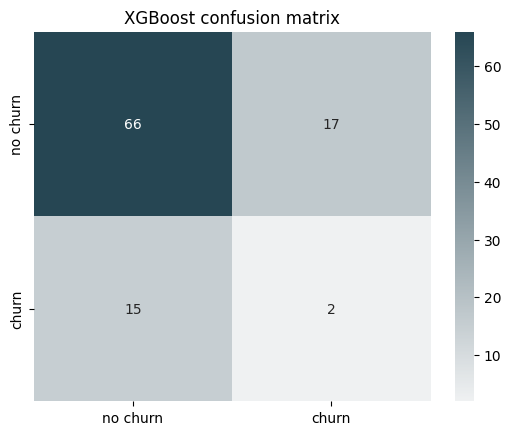

In [131]:
sns.heatmap(confusion_matrix(y_test_arr, y_pred_xgb),
            annot=True, fmt='d',
            cmap=sns.light_palette('#264653', as_cmap=True),
            xticklabels=['no churn', 'churn'],
            yticklabels=['no churn', 'churn'])
plt.title('XGBoost confusion matrix')
plt.show()

#### XGBoost — Interpretation
- AUC-ROC: 0.546 | Recall (churners): 0.12
- `scale_pos_weight` used to handle class imbalance (XGBoost equivalent
  of `class_weight='balanced'`)
- Slightly better than baseline on churners but still poor overall.
- Cross-validation mean AUC-ROC ~0.50 confirms weak signal, no overfitting.

**Confusion Matrix (XGBoost)**
- Out of 17 actual churners, the model correctly identified only 2 (Recall = 12%).
- Out of 83 non-churners, 66 were correctly predicted.
- The model struggles significantly with the minority class — 15 churners were missed entirely (false negatives).

### Model Comparison & Conclusion

| Model | AUC-ROC | Recall (churners) |
|-------|---------|-------------------|
| Baseline | — | 0.00 |
| Logistic Regression | 0.580 | 0.53 |
| Random Forest | 0.569 | 0.00 |
| XGBoost | 0.546 | 0.12 |

All three models perform poorly — AUC-ROC values are only slightly above
random (0.50). This is consistent with EDA findings: no single feature
dominates churn, and the signal is weak and distributed across variables.

This is not a failure of the modeling process. Analysis of a synthetically
generated dataset revealed weak predictive signal by design — a finding
that highlights the importance of data quality in real-world ML projects.
With real behavioral data, richer temporal features (e.g. days to churn,
usage trends over time) would likely produce stronger signals.

**Our initial targets were AUC-ROC > 0.80 and Recall > 70% — not achieved.**

**Best model: Logistic Regression (AUC-ROC = 0.58).**

## SHAP

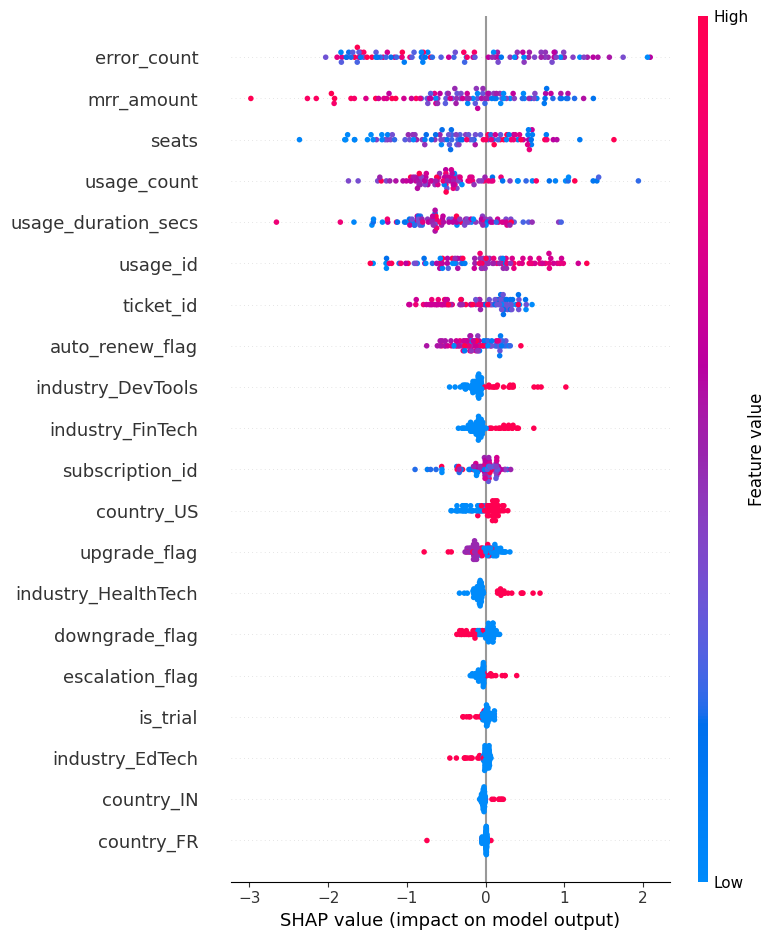

In [132]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

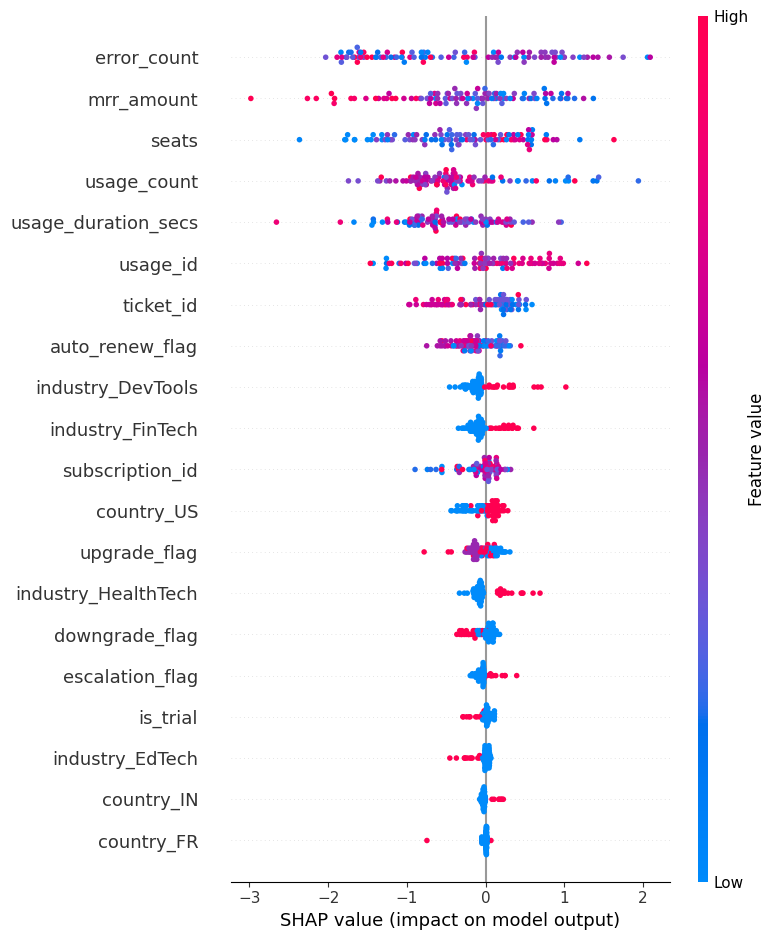

In [133]:
shap.summary_plot(shap_values, X_test)

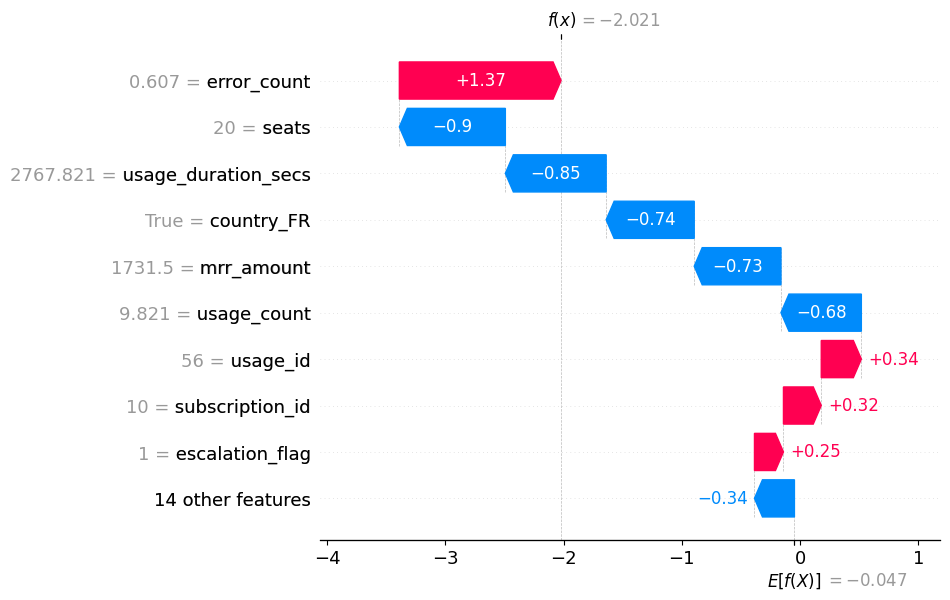

In [134]:
# Find the first churner in the test set
churner_idx = list(y_test_arr).index(True)
shap.plots.waterfall(shap_values[churner_idx])

## SHAP Analysis

SHAP (SHapley Additive exPlanations) measures the contribution of each
feature to the model's prediction. Unlike standard feature importance
(global and static), SHAP provides both:
- **Global interpretability** — which features matter most across all accounts
- **Local interpretability** — why the model made a specific prediction
  for a single account

### Global Summary Plot

The summary plot confirms the feature importance ranking from Random Forest:
`error_count` and `mrr_amount` are the most influential features overall.

Key insights from the summary plot:
- **error_count:** distributed on both sides — consistent with EDA finding
  that technical friction alone does not drive churn.
- **mrr_amount (high values → left of zero):** higher MRR pushes toward
  no churn — paying customers tend to stay.

  Note: in EDA, churned accounts showed a slightly higher average MRR
(\$2,426) compared to active ones (\$2,251). This seems to contradict
the SHAP finding. The difference is that EDA looks at raw averages,
while SHAP controls for all other variables simultaneously. When
holding other features constant, high MRR is actually associated
with retention — the EDA signal was influenced by confounding variables.

- **seats (high values → right of zero):** more licenses pushes toward
  churn — larger accounts may have higher expectations and are more likely
  to evaluate alternatives.

### Local Waterfall Plot — Single Account Analysis

The waterfall plot explains why the model predicted no churn for a specific
account that actually churned (false negative).

Starting from the average model output (E[f(X)] = -0.047), each feature
shifts the prediction:
- `error_count = 0.607` → pushes toward churn (+1.37) 🔴
- `seats = 20` → pushes toward no churn (-0.90) 🔵
- `usage_duration_secs = 2767` → pushes toward no churn (-0.85) 🔵
- `mrr_amount = 1731` → pushes toward no churn (-0.73) 🔵

Final prediction: `f(x) = -2.021` → model predicts no churn.

The model was wrong. This account churned despite having usage patterns
and MRR values typical of a retained customer — making it a hard case
to catch.

In a production setting, ambiguous cases like this would be
flagged for manual review by the customer success team.

## Business Conclusion

### What We Found
No single feature dominates churn — it is not driven by technical errors,
support experience, or product usage alone. The signal is weak and
distributed across variables, making automated prediction difficult
with the current data.

### Revenue at Risk
- **\$1.17M/month** in MRR has already been lost from churned accounts
- **\$10.16M/month** in active MRR remains at risk
- **10.4% of total MRR** lost to churn to date

Churned accounts had a slightly higher average MRR (\$2,426) than active
ones (\$2,251) — meaning RavenStack is losing its most valuable customers,
not trial or marginal accounts.

### What the Business Should Do
1. **Prioritize retention of high-MRR accounts** — manually investigate
   accounts with above-average MRR showing any early warning signals
   (declining usage, support escalations, downgrades).
2. **Invest in the retention funnel** — since no single churn driver
   dominates, a broad retention strategy is needed: proactive outreach,
   pricing reviews, and feature gap analysis based on churn reason codes.
3. **Improve data collection** — with richer temporal data (usage trends
   over time, days since last login, NPS scores) a more accurate
   prediction model could be built.

### Limitations
This analysis is based on a synthetically generated dataset. Results
should be validated on real behavioral data before informing business
decisions.